# 🔮 Material Aging — Predictive Model

**Author:** Jose Alberto  
**Date:** March 2026  
**Depends on:** `material_aging_raw.csv`

---

## 🎯 Business Context

In the current process, materials are escalated to management **after** they cross a critical aging threshold. By that point, the options are limited: sell to a subsidiary, request an emergency production order, or accept the scrap cost.

The root problem is not the decision — it's the **timing**. Without a forward-looking tool, the review process only activates when the damage is already done.

This notebook builds a predictive model that answers the question:

> *Which materials will cross a critical aging threshold (60, 90, or 120 days) in the next 30 days — before it happens?*

We approach this in two stages:
1. **Rule-based model** — deterministic, fully explainable to the business
2. **Machine Learning model (Random Forest)** — learns patterns beyond simple time rules

Both models are compared at the end to evaluate which one provides the most actionable output.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

BAND_COLORS = {
    '0-30':   '#2ecc71',
    '31-60':  '#f1c40f',
    '61-90':  '#e67e22',
    '91-120': '#e74c3c',
    '121+':   '#7f0000',
}
BAND_ORDER    = ['0-30', '31-60', '61-90', '91-120', '121+']
DATE_CURRENT  = pd.Timestamp('2026-03-13')
THRESHOLDS    = [60, 90, 120]   # Days that trigger escalation
HORIZON_DAYS  = 30              # Prediction window

BASE = Path(r"C:\Users\Beto\Portafolio Beto\Aging")
df   = pd.read_csv(BASE / "Data" / "material_aging_raw.csv", parse_dates=['Input Date'])
df['Days in Stock'] = (DATE_CURRENT - df['Input Date']).dt.days

print(f"✅ Dataset loaded: {df.shape[0]:,} records")
print(f"   Prediction horizon : {HORIZON_DAYS} days")
print(f"   Critical thresholds: {THRESHOLDS} days")
df.head()

✅ Dataset loaded: 333 records
   Prediction horizon : 30 days
   Critical thresholds: [60, 90, 120] days


,Material Code,Material Desc,Product Type,Material Type,UoM,Qty,Amt,Input Date,Days in Stock,Aging Band
0,PR-00001,Componente para Refrigerador 00001,Raw Material,Partes para Refrigeradores,PC,2296.0,851517.52,2026-01-18,54,31-60
1,PR-00002,Componente para Refrigerador 00002,Raw Material,Partes para Refrigeradores,PC,3592.0,445408.00,2025-10-20,144,121+
2,PR-00003,Componente para Refrigerador 00003,Raw Material,Partes para Refrigeradores,PC,8938.0,1926675.28,2025-12-20,83,61-90
3,PR-00004,Componente para Refrigerador 00004,Raw Material,Partes para Refrigeradores,PC,2625.0,924236.25,2025-12-17,86,61-90
4,PR-00004,Componente para Refrigerador 00004,Raw Material,Partes para Refrigeradores,PC,5524.0,331881.92,2026-03-03,10,0-30


---
## 2. Feature Engineering

Before building any model, we need to create the features (variables) that describe each material's aging behavior.  
This step translates business knowledge into numerical signals the model can use.

Features we create:
- **days_to_60 / days_to_90 / days_to_120** — how many days until each threshold is reached
- **pct_of_threshold** — how close the material is to the next threshold (0 to 1)
- **amt_per_day** — financial exposure accumulation rate
- **is_at_risk** — already in risk zone (>60 days)
- **next_threshold** — which threshold will be crossed next

These features encode the same logic a supply chain analyst applies mentally when reviewing the aging report.

In [2]:
# ── Aggregate to material level ───────────────────────
GROUP_KEYS = ['Material Code', 'Material Desc', 'Product Type', 'Material Type', 'UoM']

features = (
    df.groupby(GROUP_KEYS)
    .agg(
        Total_Qty        = ('Qty',            'sum'),
        Total_Amt        = ('Amt',            'sum'),
        Max_Days         = ('Days in Stock',  'max'),
        Avg_Days         = ('Days in Stock',  'mean'),
        Batch_Count      = ('Days in Stock',  'count'),
    )
    .reset_index()
)

# ── Days to each critical threshold ──────────────────
for t in THRESHOLDS:
    features[f'days_to_{t}'] = (t - features['Max_Days']).clip(lower=0)

# ── Next threshold each material will cross ──────────
def next_threshold(days):
    for t in THRESHOLDS:
        if days < t:
            return t
    return None   # Already past all thresholds

features['Next_Threshold']    = features['Max_Days'].apply(next_threshold)
features['Days_to_Next']      = features.apply(
    lambda r: r['Next_Threshold'] - r['Max_Days'] if r['Next_Threshold'] else 0, axis=1
)

# ── Proximity to next threshold (0 = just passed, 1 = far away) ──
features['Pct_to_Next']       = features.apply(
    lambda r: r['Days_to_Next'] / r['Next_Threshold'] if r['Next_Threshold'] else 0, axis=1
)

# ── Financial exposure rate ───────────────────────────
features['Amt_per_Day']       = (features['Total_Amt'] / features['Max_Days'].replace(0, 1)).round(2)
features['Is_At_Risk']        = (features['Max_Days'] > 60).astype(int)

# ── Projected days in stock at end of prediction horizon ──
features['Projected_Days']    = features['Max_Days'] + HORIZON_DAYS

print(f"✅ Features built for {len(features):,} materials")
print(f"\n📋 Feature summary:")
features[['Max_Days','days_to_60','days_to_90','days_to_120',
          'Days_to_Next','Pct_to_Next','Amt_per_Day','Is_At_Risk']].describe().round(2)

✅ Features built for 135 materials

📋 Feature summary:


,Max_Days,days_to_60,days_to_90,days_to_120,Days_to_Next,Pct_to_Next,Amt_per_Day,Is_At_Risk
count,135.00,135.00,135.00,135.00,104.00,104.00,135.00,135.00
mean,109.64,7.01,19.14,38.72,19.11,0.25,41357.67,0.72
std,87.90,14.45,25.31,34.81,13.15,0.22,76640.63,0.45
min,1.00,0.00,0.00,0.00,1.00,0.01,475.11,0.00
25%,55.50,0.00,0.00,3.50,8.00,0.10,6248.53,0.00
50%,86.00,0.00,4.00,34.00,17.00,0.19,21548.35,1.00
75%,116.50,4.50,34.50,64.50,26.00,0.29,43646.76,1.00
max,351.00,59.00,89.00,119.00,59.00,0.98,713508.96,1.00


---
## 3. Model 1 — Rule-Based Prediction

The rule-based model is deterministic: a material **will** cross a threshold in the next 30 days if its current days in stock plus 30 exceeds that threshold.

This is the model a supply chain analyst applies manually — we are simply automating and scaling it.

**Why start here:**  
Before adding ML complexity, we establish a clear baseline. If the rule-based model already captures 90% of the risk, ML adds marginal value. If ML significantly outperforms it, the gap is worth explaining.

In [3]:
# ── Apply rules ───────────────────────────────────────
def rule_based_prediction(row):
    projected = row['Max_Days'] + HORIZON_DAYS
    crossed   = [t for t in THRESHOLDS if row['Max_Days'] < t <= projected]
    if not crossed:
        return 'No Risk'
    # Return the most critical threshold that will be crossed
    return f'Will cross {max(crossed)}d'

features['Rule_Prediction'] = features.apply(rule_based_prediction, axis=1)

# ── Estimate projected amount at risk ─────────────────
features['Projected_At_Risk_Amt'] = np.where(
    features['Rule_Prediction'] != 'No Risk',
    features['Total_Amt'],
    0
)

# ── Summary ───────────────────────────────────────────
rule_summary = features['Rule_Prediction'].value_counts()
print("📊 Rule-based prediction summary:\n")
for label, count in rule_summary.items():
    amt = features[features['Rule_Prediction'] == label]['Total_Amt'].sum()
    icon = '✅' if label == 'No Risk' else '⚠️'
    print(f"   {icon} {label:<22} {count:>4} materials   ${amt:>14,.0f}")

total_predicted_risk = features[features['Rule_Prediction'] != 'No Risk']['Total_Amt'].sum()
print(f"\n🚨 Total projected at-risk value (next 30 days): ${total_predicted_risk:,.0f}")

📊 Rule-based prediction summary:

   ✅ No Risk                  43 materials   $   117,895,573
   ⚠️ Will cross 90d           34 materials   $    70,494,213
   ⚠️ Will cross 120d          33 materials   $    97,159,446
   ⚠️ Will cross 60d           25 materials   $    58,665,675

🚨 Total projected at-risk value (next 30 days): $226,319,335


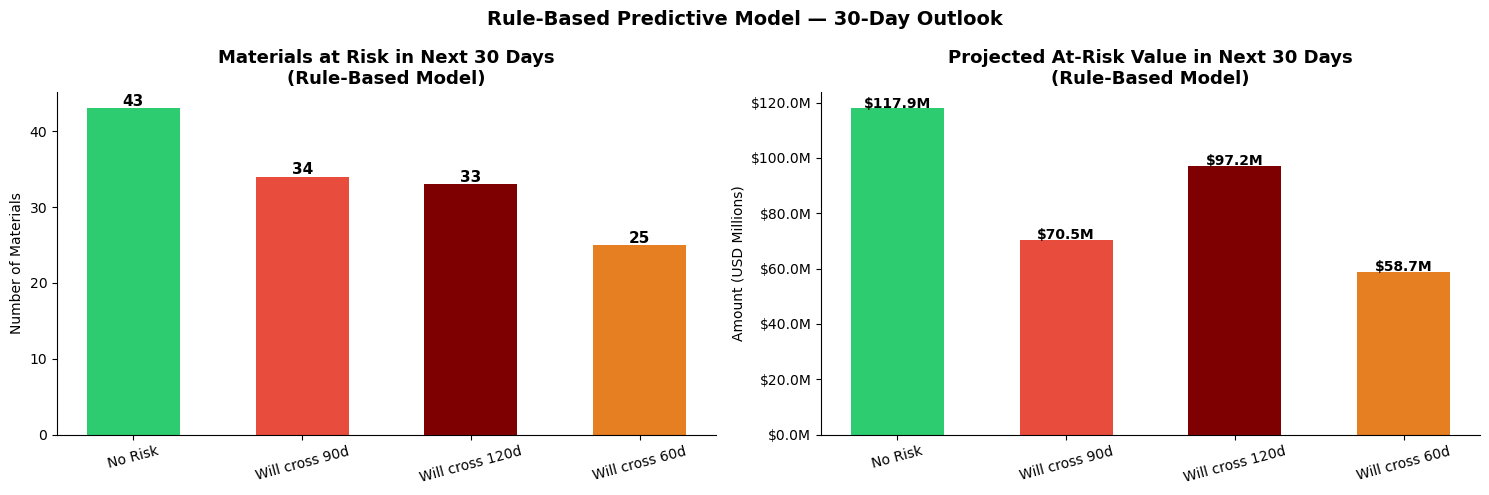

✅ Chart saved.


In [4]:
# ── Visualize rule-based results ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count by prediction label
ax1 = axes[0]
labels  = rule_summary.index.tolist()
counts  = rule_summary.values
colors  = ['#2ecc71' if l == 'No Risk' else
            '#e67e22' if '60' in l else
            '#e74c3c' if '90' in l else '#7f0000'
            for l in labels]
bars = ax1.bar(labels, counts, color=colors, width=0.55)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(count), ha='center', fontsize=11, fontweight='bold')
ax1.set_title(f'Materials at Risk in Next {HORIZON_DAYS} Days\n(Rule-Based Model)')
ax1.set_ylabel('Number of Materials')
ax1.tick_params(axis='x', rotation=15)

# Amount at risk by prediction label
ax2 = axes[1]
amt_by_label = features.groupby('Rule_Prediction')['Total_Amt'].sum().reindex(labels)
bars2 = ax2.bar(labels, amt_by_label/1e6, color=colors, width=0.55)
for bar, val in zip(bars2, amt_by_label/1e6):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'${val:.1f}M', ha='center', fontsize=10, fontweight='bold')
ax2.set_title(f'Projected At-Risk Value in Next {HORIZON_DAYS} Days\n(Rule-Based Model)')
ax2.set_ylabel('Amount (USD Millions)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.1f}M'))
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('Rule-Based Predictive Model — 30-Day Outlook', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "09_rule_based_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

In [5]:
# ── Priority list for management escalation ───────────
at_risk_materials = (
    features[features['Rule_Prediction'] != 'No Risk']
    [['Material Code','Material Desc','Material Type','Product Type',
      'Max_Days','Days_to_Next','Next_Threshold','Total_Amt','Rule_Prediction']]
    .sort_values(['Days_to_Next','Total_Amt'], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"📋 Priority escalation list — {len(at_risk_materials)} materials at risk:\n")
print(f"{'#':<4} {'Material':<12} {'Description':<30} {'Max Days':>9} {'Days Left':>10} {'Next Threshold':>15} {'Total Amt':>14}")
print("-" * 100)
for i, row in at_risk_materials.iterrows():
    urgency = '🔴' if row['Days_to_Next'] <= 7 else '⚠️' if row['Days_to_Next'] <= 15 else '🟡'
    print(f"{i+1:<4} {row['Material Code']:<12} {row['Material Desc'][:29]:<30} "
          f"{row['Max_Days']:>9.0f} {row['Days_to_Next']:>10.0f} "
          f"{str(row['Next_Threshold'])+'d':>15} ${row['Total_Amt']:>13,.0f}  {urgency}")

📋 Priority escalation list — 92 materials at risk:

#    Material     Description                     Max Days  Days Left  Next Threshold      Total Amt
----------------------------------------------------------------------------------------------------
1    PR-00005     Componente para Refrigerador         119          1          120.0d $    5,139,088  🔴
2    R-00010      Resina 00010                          59          1           60.0d $      115,572  🔴
3    PL-00013     Componente para Lavadora 0001        118          2          120.0d $    4,845,295  🔴
4    PI-00015     Parte Inyectada 00015                 58          2           60.0d $    2,518,176  🔴
5    PQ-00006     Producto Quimico 00006                88          2           90.0d $      456,909  🔴
6    R-00003      Resina 00003                         118          2          120.0d $      220,762  🔴
7    LV-00011     Lavadora 00011                        87          3           90.0d $    3,817,274  🔴
8    PR-00004     

---
## 4. Model 2 — Random Forest Classifier

The rule-based model is transparent but limited — it only considers days in stock.  
The Random Forest model learns from **multiple features simultaneously**: amount, quantity, batch count, proximity to threshold, and material type.

**Target variable:** Will this material cross any critical threshold in the next 30 days? (1 = Yes, 0 = No)  

We use the rule-based prediction as the **ground truth label** to train the model.  
In a production environment with historical data, this would be replaced by actual observed outcomes.

In [6]:
# ── Prepare ML dataset ────────────────────────────────
ml_df = features.copy()

# Target: will cross any threshold in next 30 days?
ml_df['Target'] = (ml_df['Rule_Prediction'] != 'No Risk').astype(int)

# Encode categorical features
le_product  = LabelEncoder()
le_material = LabelEncoder()
ml_df['Product_Type_Enc']  = le_product.fit_transform(ml_df['Product Type'])
ml_df['Material_Type_Enc'] = le_material.fit_transform(ml_df['Material Type'])

FEATURE_COLS = [
    'Max_Days', 'Avg_Days', 'Total_Amt', 'Total_Qty',
    'Batch_Count', 'Amt_per_Day', 'Pct_to_Next',
    'days_to_60', 'days_to_90', 'days_to_120',
    'Is_At_Risk', 'Product_Type_Enc', 'Material_Type_Enc'
]

X = ml_df[FEATURE_COLS]
y = ml_df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"✅ ML dataset prepared:")
print(f"   Training samples : {len(X_train)}")
print(f"   Test samples     : {len(X_test)}")
print(f"   Class balance    : {y.value_counts().to_dict()} (0=No Risk, 1=At Risk)")

✅ ML dataset prepared:
   Training samples : 101
   Test samples     : 34
   Class balance    : {1: 92, 0: 43} (0=No Risk, 1=At Risk)


In [7]:
# ── Train Random Forest ───────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained")
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Risk', 'At Risk']))

✅ Random Forest trained

📊 Classification Report:

              precision    recall  f1-score   support

     No Risk       1.00      1.00      1.00        11
     At Risk       1.00      1.00      1.00        23

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



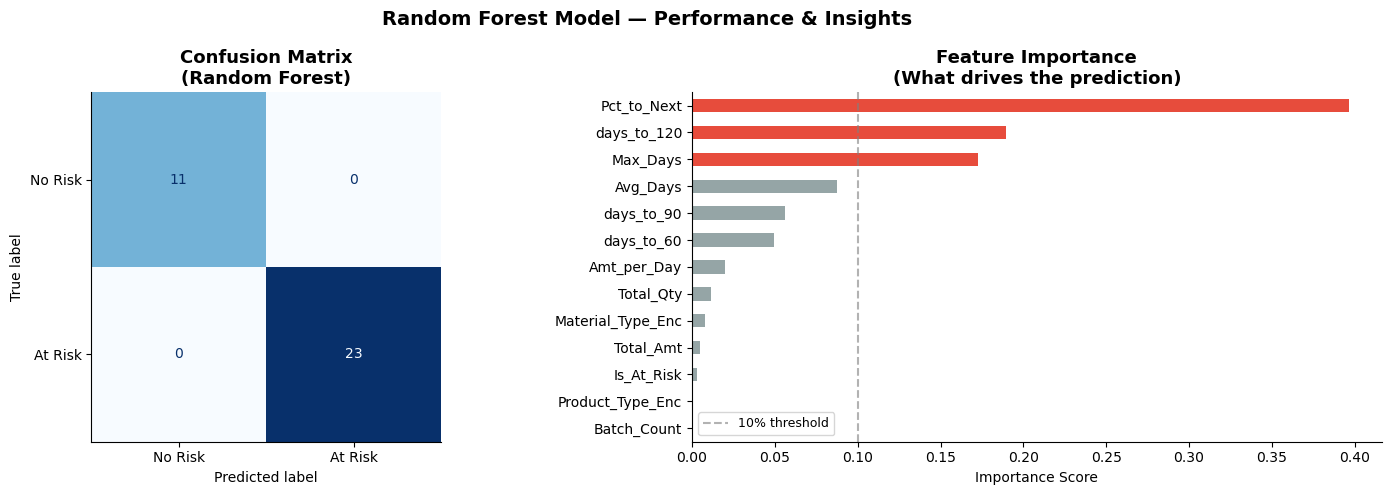

✅ Chart saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Confusion matrix ──────────────────────────────────
ax1 = axes[0]
cm  = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Risk', 'At Risk'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix\n(Random Forest)')

# ── Feature importance ────────────────────────────────
ax2 = axes[1]
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)
colors_imp  = ['#e74c3c' if imp > 0.1 else '#95a5a6' for imp in importances]
importances.plot(kind='barh', ax=ax2, color=colors_imp)
ax2.set_title('Feature Importance\n(What drives the prediction)')
ax2.set_xlabel('Importance Score')
ax2.axvline(0.1, color='gray', linestyle='--', alpha=0.6, label='10% threshold')
ax2.legend(fontsize=9)

plt.suptitle('Random Forest Model — Performance & Insights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "10_random_forest_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 5. Model Comparison

Both models answer the same question. Here we compare their outputs to understand:
- Where they agree (high confidence predictions)
- Where they disagree (materials the ML model flags that rules miss, and vice versa)

In [9]:
# ── Apply RF to full dataset ──────────────────────────
ml_df['RF_Prediction']    = rf_model.predict(X)
ml_df['RF_Probability']   = rf_model.predict_proba(X)[:, 1].round(3)

ml_df['Rule_Binary']      = (ml_df['Rule_Prediction'] != 'No Risk').astype(int)

def compare_models(row):
    rule = row['Rule_Binary']
    rf   = row['RF_Prediction']
    if rule == 1 and rf == 1:   return 'Both flag risk'
    elif rule == 1 and rf == 0: return 'Rule only'
    elif rule == 0 and rf == 1: return 'ML only'
    else:                       return 'Both clear'

ml_df['Model_Agreement'] = ml_df.apply(compare_models, axis=1)

agreement_summary = ml_df['Model_Agreement'].value_counts()
print("📊 Model comparison summary:\n")
for label, count in agreement_summary.items():
    amt = ml_df[ml_df['Model_Agreement'] == label]['Total_Amt'].sum()
    icon = '🔴' if 'risk' in label.lower() else '⚠️' if 'only' in label.lower() else '✅'
    print(f"   {icon} {label:<22} {count:>4} materials   ${amt:>14,.0f}")

ml_only = ml_df[ml_df['Model_Agreement'] == 'ML only'].sort_values('RF_Probability', ascending=False)
if len(ml_only) > 0:
    print(f"\n⚠️  Materials flagged by ML but NOT by rules ({len(ml_only)}) — these are hidden risks:")
    print(ml_only[['Material Code','Material Desc','Max_Days','RF_Probability','Total_Amt']]
          .head(10).to_string(index=False))

📊 Model comparison summary:

   🔴 Both flag risk           92 materials   $   226,319,335
   ✅ Both clear               43 materials   $   117,895,573


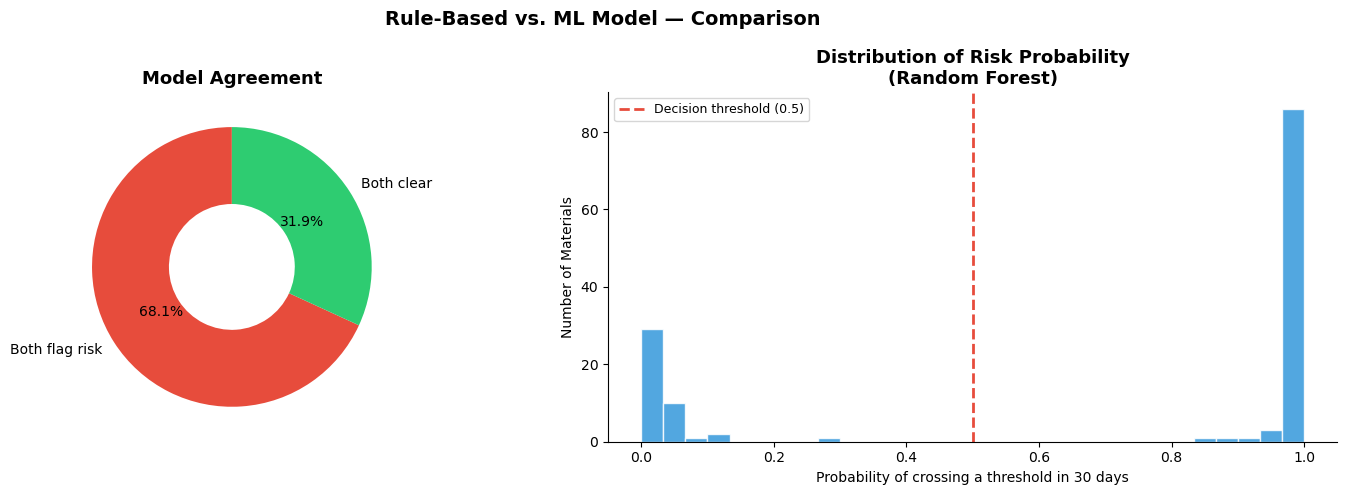

✅ Chart saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Agreement pie chart ───────────────────────────────
ax1 = axes[0]
agree_colors = {
    'Both flag risk': '#e74c3c',
    'Rule only':      '#e67e22',
    'ML only':        '#9b59b6',
    'Both clear':     '#2ecc71'
}
wedge_colors = [agree_colors.get(l, '#95a5a6') for l in agreement_summary.index]
ax1.pie(agreement_summary.values, labels=agreement_summary.index,
        colors=wedge_colors, autopct='%1.1f%%',
        wedgeprops=dict(width=0.55), startangle=90,
        textprops={'fontsize': 10})
ax1.set_title('Model Agreement')

# ── RF Probability distribution ───────────────────────
ax2 = axes[1]
ax2.hist(ml_df['RF_Probability'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
ax2.axvline(0.5, color='#e74c3c', linestyle='--', linewidth=2, label='Decision threshold (0.5)')
ax2.set_title('Distribution of Risk Probability\n(Random Forest)')
ax2.set_xlabel('Probability of crossing a threshold in 30 days')
ax2.set_ylabel('Number of Materials')
ax2.legend(fontsize=9)

plt.suptitle('Rule-Based vs. ML Model — Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "11_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 6. Final Prioritized Output — Escalation List

The final deliverable is a single, prioritized list combining both models.  
This is what gets sent to the operations manager every Friday — replacing the manual escalation process.

In [11]:
# ── Build final escalation table ─────────────────────
escalation = ml_df[['Material Code','Material Desc','Product Type','Material Type',
                     'Max_Days','Days_to_Next','Next_Threshold','Total_Amt',
                     'Rule_Prediction','RF_Probability','Model_Agreement']].copy()

# Priority score: combines both models and financial exposure
escalation['Priority_Score'] = (
    escalation['RF_Probability'] * 0.4 +
    (1 - escalation['Days_to_Next'].clip(0,30) / 30) * 0.4 +
    (escalation['Total_Amt'] / escalation['Total_Amt'].max()) * 0.2
).round(4)

def escalation_level(row):
    if row['Model_Agreement'] == 'Both flag risk' and row['Days_to_Next'] <= 7:
        return '🔴 ESCALATE NOW'
    elif row['Model_Agreement'] == 'Both flag risk':
        return '🟠 ESCALATE THIS WEEK'
    elif row['Model_Agreement'] in ('Rule only','ML only'):
        return '⚠️  MONITOR'
    else:
        return '✅ CLEAR'

escalation['Escalation'] = escalation.apply(escalation_level, axis=1)

# Export to Excel
escalation_sorted = escalation[escalation['Escalation'] != '✅ CLEAR'] \
    .sort_values('Priority_Score', ascending=False)

export_path = BASE / "Outputs" / "30day_escalation_list.xlsx"
escalation_sorted.to_excel(export_path, index=False)
print(f"✅ Escalation list exported: {export_path}")
print(f"\n📋 Summary:")
print(escalation['Escalation'].value_counts().to_string())

✅ Escalation list exported: C:\Users\Beto\Portafolio Beto\Aging\Outputs\30day_escalation_list.xlsx

📋 Summary:
Escalation
🟠 ESCALATE THIS WEEK    68
✅ CLEAR                 43
🔴 ESCALATE NOW          24


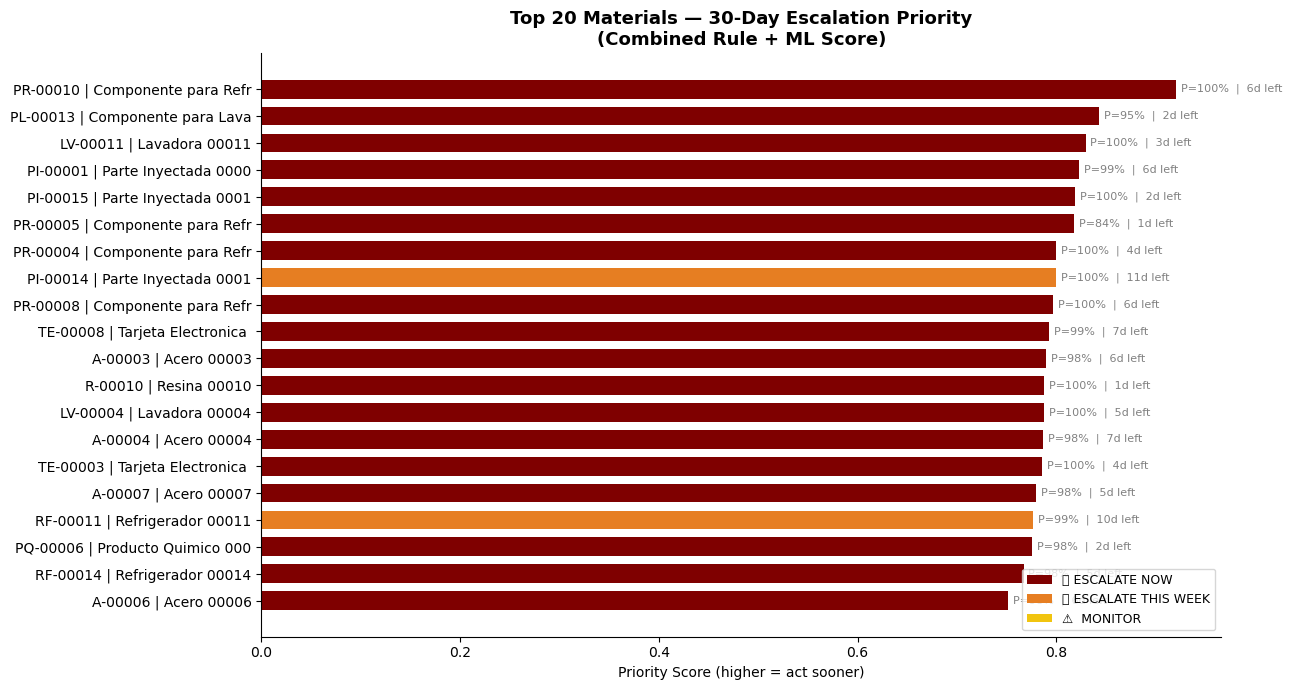

✅ Chart saved.


In [12]:
# ── Final visualization: Top 20 by priority ───────────
top20 = escalation_sorted.head(20)

fig, ax = plt.subplots(figsize=(13, 7))

colors_esc = [
    '#7f0000' if '🔴' in e else
    '#e67e22' if '🟠' in e else '#f1c40f'
    for e in top20['Escalation']
]
label = top20['Material Code'] + ' | ' + top20['Material Desc'].str[:20]
bars  = ax.barh(label, top20['Priority_Score'], color=colors_esc, height=0.7)

for bar, prob, days in zip(bars, top20['RF_Probability'], top20['Days_to_Next']):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'P={prob:.0%}  |  {days:.0f}d left',
            va='center', fontsize=8, color='gray')

ax.set_title(f'Top 20 Materials — 30-Day Escalation Priority\n(Combined Rule + ML Score)',
             fontsize=13)
ax.set_xlabel('Priority Score (higher = act sooner)')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#7f0000', label='🔴 ESCALATE NOW'),
    Patch(facecolor='#e67e22', label='🟠 ESCALATE THIS WEEK'),
    Patch(facecolor='#f1c40f', label='⚠️  MONITOR'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(BASE / "Outputs" / "12_escalation_priority.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved.")

---
## 7. Key Findings & Recommendations

> ✏️ *Update this section with the actual numbers after running the notebook.*

### 📊 Model Summary

| Metric | Rule-Based | Random Forest |
|---|---|---|
| Materials flagged at risk | `XX` | `XX` |
| Projected at-risk value | `$XXX,XXX,XXX` | `$XXX,XXX,XXX` |
| Hidden risks (ML only) | — | `XX` |
| Model agreement | — | `XX%` |
| Top feature driving prediction | — | `XXX` |

### 🔎 Observations
1. **[Rule-based findings]** — How many materials will cross each threshold and when?
2. **[ML added value]** — Did the Random Forest find materials the rules missed?
3. **[Feature importance]** — What is the strongest predictor beyond days in stock?

### 💡 Recommendations

1. **Replace manual escalation with this output**  
   The current process escalates materials to management only after they cross a threshold — at which point options are limited to subsidiary sales or scrap. The `30day_escalation_list.xlsx` provides a 30-day advance warning, giving the operations team time to plan consumption, adjust production schedules, or negotiate returns before the financial impact materializes.

2. **Prioritize ESCALATE NOW materials**  
   Materials flagged by both models with fewer than 7 days before crossing a threshold require an immediate decision. Delay beyond this point significantly reduces the probability of a subsidiary sale at full value.

3. **Investigate ML-only flags**  
   Materials the Random Forest flags but rules do not are the most interesting findings — they represent non-obvious patterns (e.g., high value, multiple batches, specific material types) that the rule-based approach cannot detect. Each one deserves a manual review.

4. **Operationalize the model**  
   The long-term recommendation is to automate this notebook as a weekly scheduled process — extracting data directly from the SAP Z-report, running both models, and distributing the escalation list to the operations manager every Friday morning before the weekly review meeting.

---
## 8. Project Summary

This three-notebook project transforms a manual, reactive Excel-based aging report into a fully automated, predictive inventory intelligence system.

| Notebook | Before | After |
|---|---|---|
| 01 — EDA | Static Excel snapshot | Automated aging analysis with visualizations |
| 02 — Comparative | Manual week-over-week pivot | Automated movement detection with migration matrix |
| 03 — Predictive | No forward visibility | 30-day risk prediction with prioritized escalation list |

**Business impact:** Earlier intervention on at-risk inventory reduces the probability of scrap, preserves the option of subsidiary sales at full value, and provides management with a data-driven escalation process instead of a time-sensitive reactive one.

**Technical stack:** Python (Pandas, Scikit-learn, Matplotlib) · SQL · Looker Studio